In [1]:
import dataset as ds
from dataset import TensorToImg, ImgWrite, ImgRead, ImgToTensor
# dt = ds.Coco("/home/wanderer2414/coco2017/")
from torch.utils.data import DataLoader
from dataset2 import YOLODataset, collect_fn
import config
from torch import tensor, arange, float as tfloat, stack
import matplotlib.pyplot as plt
import matplotlib.patches as pat
# dt = ds.Coco("/home/wanderer2414/PASCAL_VOC")
train_data = YOLODataset("/home/wanderer2414/PASCAL_VOC/train.csv", "/home/wanderer2414/PASCAL_VOC/images/", "/home/wanderer2414/PASCAL_VOC/labels/", config.ANCHORS, transform=config.train_transforms)
test_data = YOLODataset("/home/wanderer2414/PASCAL_VOC/test.csv", "/home/wanderer2414/PASCAL_VOC/images/", "/home/wanderer2414/PASCAL_VOC/labels/", config.ANCHORS, transform=config.test_transforms)
train_loader = DataLoader(train_data, 8, collate_fn=collect_fn, num_workers=4)
test_loader = DataLoader(test_data, 1, collate_fn=collect_fn, num_workers=1)
# for tens, labels in train_loader:
    # print(labels.shape)
    # pass
# coco = YOLODataset("../COCO/test.csv", "../COCO/")
# loader = DataLoader

/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/wanderer2414/MyRCNN/config.py:65: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/home/wanderer2414/MyRCNN/config.py:75: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(
/home/wanderer2414/MyRCNN/config.py:78: UserWarning: Argument(s) 'mode, cval' are not valid for transform Affine
  A.Affine(shear=15, p=0.5, mode=cv2.BORDER_CONSTANT, cval=0), # Updated from deprecated IAAAffin

In [2]:
# import MyRCNN
# import torch
# dev = "cpu"
# model = MyRCNN.Model(device=torch.device(dev))
# model.model.load_state_dict(torch.load("bbx.pth", map_location=dev))
def count_parameters(model):
        return sum(p.numel() for p in model.parameters())

# print(count_parameters(model.model.color))

In [3]:
import MyRCNN
import torch
device = "cpu"
model = MyRCNN.Model(train_loader, test_loader, len(config.PASCAL_CLASSES), device=torch.device(device))
print(count_parameters(model.model))
# for module in model.model.color.prepare.modules():
#     print(module)
model.train()

893
Load model!
Load model!


In [4]:
# model.Evaluate()

torch.Size([1, 5])
torch.Size([32, 5])
tensor([  0.0000, 283.8234, 118.3615, 283.8234, 118.3578],
       grad_fn=<SelectBackward0>)
tensor([  0.0000, 154.5897, 198.7514, 154.5889, 198.7466],
       grad_fn=<SelectBackward0>)
tensor([  0.0000, 262.6961,  38.7280, 262.6971,  38.7319],
       grad_fn=<SelectBackward0>)
tensor([  0.0000, 157.2574, 201.9993, 157.2567, 201.9948],
       grad_fn=<SelectBackward0>)
tensor([  0.0000, 155.5303, 201.4491, 155.5300, 201.4457],
       grad_fn=<SelectBackward0>)
tensor([  0.0000, 164.6257, 202.6751, 164.6170, 202.6658],
       grad_fn=<SelectBackward0>)
tensor([  0.0000, 260.0459,  38.7799, 260.0457,  38.7790],
       grad_fn=<SelectBackward0>)
tensor([  0.0000, 306.0187, 232.5214, 306.0247, 232.5280],
       grad_fn=<SelectBackward0>)
tensor([  0.0000, 306.1134, 232.1354, 306.1140, 232.1365],
       grad_fn=<SelectBackward0>)
tensor([  0.0000, 284.9089, 121.5479, 284.9085, 121.5398],
       grad_fn=<SelectBackward0>)
tensor([  0.0000, 194.6857, 204

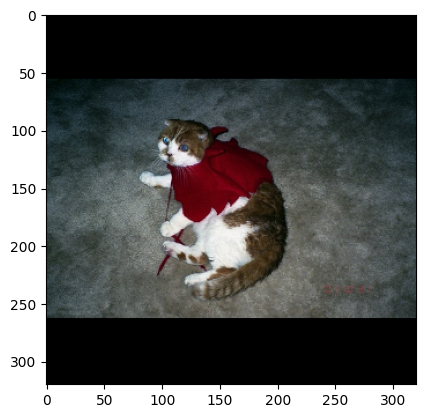

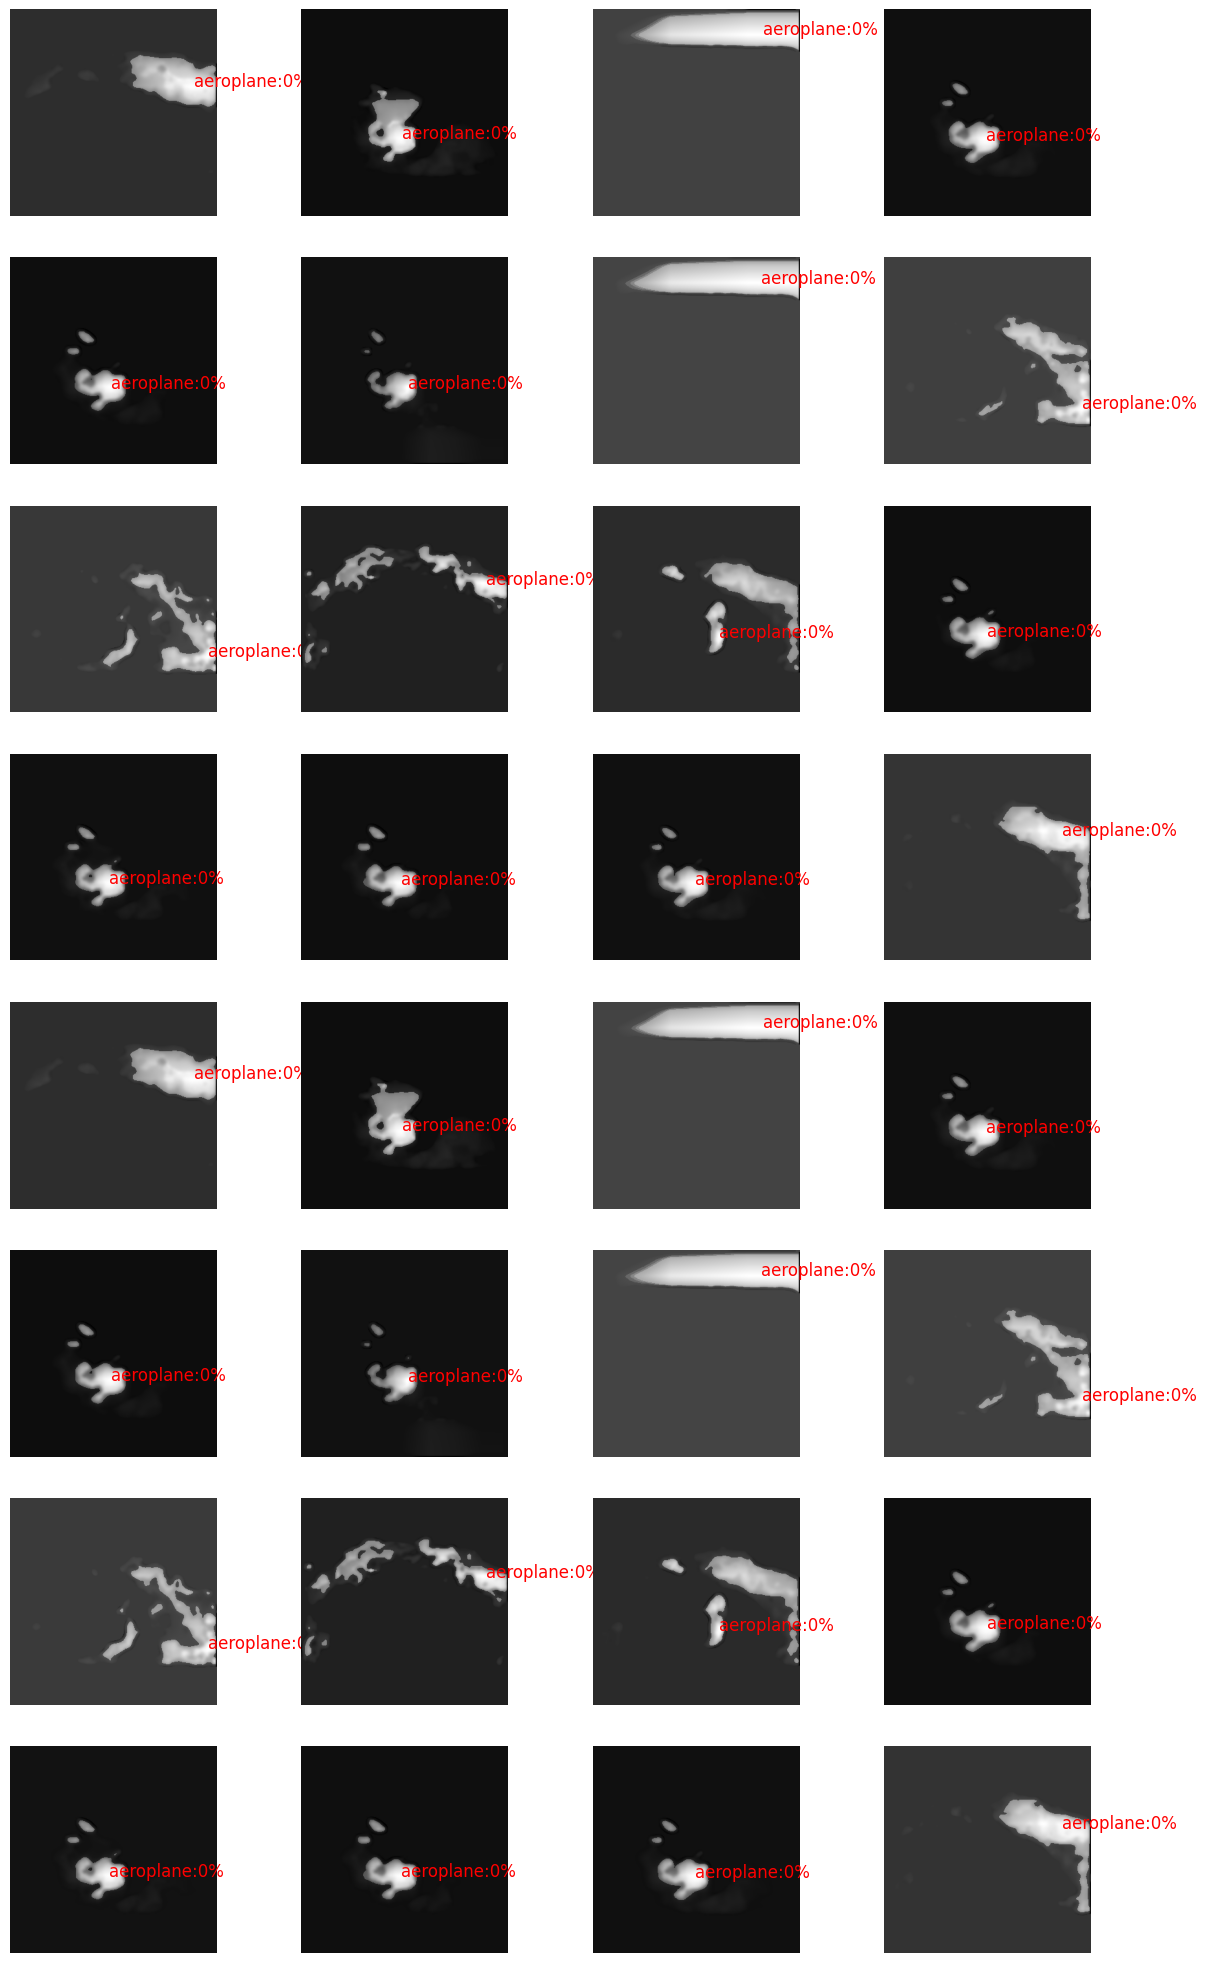

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as pat
from torch import sigmoid, softmax, zeros, bool as tbool
from dataset import TensorToImg, ImgToTensor
i = 6
X:torch.Tensor
x, label = test_data[i]
x = x.to(device=torch.device(device))
# label = test_data[i][0][1]
print(label.shape)
# print(label.shape)
x = x.unsqueeze(0)
boundary, mask, color, score, boxes = model.model(x)
boxes = boxes[:, :-1]
cls = model.cls(boundary, mask, color, boxes)
print(boxes[0])
# x1, y1, x2, y2, cls = label[0]
# rect = pat.Rectangle((x1, y1), x2-x1, y2-y1, facecolor='none', edgecolor='blue')
# plt.subplot().add_patch(rect)
# plt.imshow(TensorToImg(x.detach().cpu()))

# boxes = model.inference(x)

N = color.shape[1]
# boxes = boxes.view(N, -1, 6).permute(0, 2, 1)
# tv = sigmoid(boxes[:, :, 19].flatten())
# print((tv*100).long())
# boxes = boxes.view(N, -1, 6)
# cls = softmax(boxes[:, :, 1:2].view(N, -1), dim=-1)
# indices = cls.max(dim=-1).indices.view(-1, 1)
# indices = zeros(indices.shape[0], 20, dtype=tbool, device=indices.device).scatter(-1, indices, True).unsqueeze(-1).expand(-1, 20, 6)
# boxes = boxes[indices].view(N, 6)
# plt.imshow(TensorToImg(x))
# cls = softmax(boxes, dim=-1)
# print(boxes.shape)
# box_show = boxes.permute(0, 2, 1).reshape(-1, 20)
# print(box_show.shape)
# print((box_show[:, 19]*100).long())
# fig, axes = plt.subplots(N//4, 4, figsize=(12, 20))
# cls_range = arange(20).view(20, 1, 1).expand(20, N, 1)
# for i, ax in enumerate(axes.flat):
#     x = color[:, i:i+1, :, :]
#     x = x.repeat(1, 3, 1, 1)
#     x = x-x.min()
#     x = x/x.max()
#     cls, x1, y1, x2, y2 = boxes[i].detach().cpu().numpy()
#     print(boxes[i])
#     rect = pat.Rectangle((x1, y1), x2-x1, y2-y1, facecolor='none', edgecolor='red')
#     ax.add_patch(rect)
#     ax.text((x1+x2)/2, (y1+y2)/2, f"{config.PASCAL_CLASSES[cls.astype(int)]}:{0}%", fontsize=12, color='red')
#     ax.imshow(TensorToImg(x.detach().cpu()))
#     ax.axis('off')
# plt.tight_layout()
# plt.show()
